# Data-Driven Analysis of the UK Railway Network

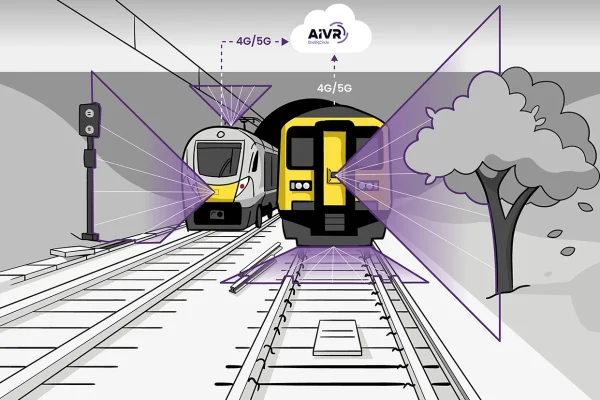

# Project Objective: UK Trains Analysis

The objective of this project is to analyze UK train data to understand performance, usage patterns, and operational efficiency across the railway network.

This project aims to:

- Examine train schedules, routes, and station activity across the UK.
- Analyze delays, cancellations, and punctuality performance.
- Identify peak travel times and high-traffic routes.
- Explore factors that may impact service reliability.
- Visualize key trends using clear and informative charts.

By transforming raw railway data into meaningful insights, this project seeks to highlight performance patterns, improve decision-making, and support recommendations for enhancing the efficiency and reliability of the UK rail system.


## Data Cleaning

### Understanding Data

In [4]:
import pandas as pd
trains=pd.read_csv('railway.csv',index_col=0)
trains.head(5)


,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
Transaction ID,,,,,,,,,,,,,,,,,
da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


### check duplicates

In [5]:
trains.duplicated().sum()

np.int64(8)

### delete duplicates

In [6]:
railway_cleaned = trains.drop_duplicates()
railway_cleaned = trains.drop_duplicates().copy()


### check missing vales

In [7]:
railway_cleaned.isnull().sum()

Date of Purchase           0
Time of Purchase           0
Purchase Type              0
Payment Method             0
Railcard               20912
Ticket Class               0
Ticket Type                0
Price                      0
Departure Station          0
Arrival Destination        0
Date of Journey            0
Departure Time             0
Arrival Time               0
Actual Arrival Time     1879
Journey Status             0
Reason for Delay       27476
Refund Request             0
dtype: int64

### Handling Missing Values


In [8]:
missing = railway_cleaned[
    (railway_cleaned['Reason for Delay'].isna()) | (railway_cleaned['Reason for Delay'] == '') |
    (railway_cleaned['Actual Arrival Time'].isna()) | (railway_cleaned['Actual Arrival Time'] == '') |
    (railway_cleaned['Railcard'].isna()) | (railway_cleaned['Railcard'] == '')
]

In [9]:
railway_cleaned['Reason for Delay'] = railway_cleaned['Reason for Delay'].replace('', 'Not Mentioned')
railway_cleaned['Reason for Delay'] = railway_cleaned['Reason for Delay'].fillna('Not Mentioned')

railway_cleaned['Railcard'] = railway_cleaned['Railcard'].replace(['', 'None'], 'No Railcard')
railway_cleaned['Railcard'] = railway_cleaned['Railcard'].fillna('No Railcard')

railway_cleaned['Actual Arrival Time'] = railway_cleaned['Actual Arrival Time'].replace('', '00:00:00')
railway_cleaned['Actual Arrival Time'] = railway_cleaned['Actual Arrival Time'].fillna('00:00:00')


### Check Outliers

In [10]:
outliers = railway_cleaned[railway_cleaned['Price'] > 300]


In [11]:
railway_cleaned.head(10)


,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
Transaction ID,,,,,,,,,,,,,,,,,
da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,Not Mentioned,No
b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No Railcard,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,Not Mentioned,No
b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No Railcard,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,Not Mentioned,No
2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No Railcard,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,Not Mentioned,No
4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,No Railcard,Standard,Advance,35,London Kings Cross,York,2024-01-01,06:15:00,08:05:00,08:05:00,On Time,Not Mentioned,No
1c74479d-85a4-4ba1-a607,2023-12-31,00:02:01,Station,Credit Card,Adult,Standard,Advance,2,London Euston,Oxford,2024-01-01,22:30:00,23:40:00,23:40:00,On Time,Not Mentioned,No
febf8dab-f808-46fa-bf2b,2023-12-31,01:35:18,Station,Contactless,Disabled,Standard,Advance,2,Liverpool Lime Street,Manchester Piccadilly,2024-01-01,00:00:00,00:30:00,00:30:00,On Time,Not Mentioned,No
01df916f-4291-41ec-a37d,2023-12-31,01:43:09,Station,Credit Card,No Railcard,Standard,Advance,37,London Euston,York,2024-01-01,00:00:00,01:50:00,02:07:00,Delayed,Signal Failure,No


## Data Analysis

### Total number of journeys and net revenue (excluding cancelled trips)


In [19]:
valid_journeys = railway_cleaned[railway_cleaned['Journey Status'] != 'Cancelled']

total_journeys = valid_journeys.shape[0]
net_revenue = valid_journeys['Price'].sum()
net_revenue,total_journeys


(np.int64(696196), 29766)

### Calc AVG Price Ticket


In [21]:
avg_ticket = railway_cleaned.groupby('Ticket Class')['Price'].mean()
avg_ticket = avg_ticket.round(0)
avg_ticket

Ticket Class
First Class    49.0
Standard       21.0
Name: Price, dtype: float64

### Ticket Class Most Commonly Purchased


In [22]:
ticket_count = railway_cleaned['Ticket Class'].value_counts()
ticket_count 

Ticket Class
Standard       28587
First Class     3058
Name: count, dtype: int64

### Distribution of passengers by railcard status


In [23]:
railcard_count = railway_cleaned['Railcard'].value_counts()
railcard_count 

Railcard
No Railcard    20912
Adult           4846
Disabled        3088
Senior          2799
Name: count, dtype: int64

### Peak Hours Passgeners Journey


In [33]:
railway_cleaned['hour'] = pd.to_datetime(railway_cleaned['Departure Time'],format='%H:%M:%S').dt.hour 
peak_hours = railway_cleaned['hour'].value_counts()
peak_hours.head(5)

hour
18    3111
6     3111
17    2887
7     2794
16    2300
Name: count, dtype: int64

### top arrival stations 


In [31]:
top_arrival = railway_cleaned['Arrival Destination'].value_counts()
top_arrival.head(7)

Arrival Destination
Birmingham New Street    7740
Liverpool Lime Street    5021
York                     4018
Manchester Piccadilly    3968
Reading                  3918
London Euston            1565
London St Pancras         749
Name: count, dtype: int64

### Top 5 cancellation reasons with number of trips and revenue lost 


In [38]:
cancelled = railway_cleaned[railway_cleaned['Journey Status'] == 'Cancelled']
cancel_reason = cancelled.groupby('Reason for Delay').agg(cancelled_trips=('Reason for Delay','count'),
revenue_lost=('Price','sum'))
cancel_reason

,cancelled_trips,revenue_lost
Reason for Delay,,
Signal Failure,281,7327
Signal failure,238,5143
Staff Shortage,216,5221
Staffing,238,6271
Technical Issue,235,4958
Traffic,227,5280
Weather,236,7098
Weather Conditions,208,4088
